## 神经网络建模流程

在本项目中，采用人工神经网络（ANN）基于多个特征对水质进行预测。神经网络在捕捉复杂且非线性的关系方面具有良好的效果。

建模过程包括以下步骤：

### 1. 数据预处理

对数据进行清洗，将其划分为训练集和测试集，并进行标准化处理，以确保训练过程的稳定性。

### 2. 模型构建

构建一个前馈神经网络，包含多个全连接层。隐藏层使用 ReLU 激活函数，输出层使用 sigmoid 激活函数以实现二分类。

### 3. 模型编译

模型采用 Adam 优化器和二元交叉熵损失函数，并设置相应的评估指标。

### 4. 模型训练

使用训练数据通过反向传播算法对模型进行训练。为处理类别不平衡问题，可以应用类别权重。

### 5. 预测与阈值调整

将模型输出的预测概率通过设定阈值转换为类别标签，并可通过调整阈值来平衡召回率和精确率。

### 6. 模型评估

使用准确率、精确率、召回率、F1 分数以及混淆矩阵对模型性能进行评估。

### 7. 解释与比较

相比逻辑回归，神经网络的可解释性较弱，但能够建模更复杂的模式。因此，通常会将其结果与简单模型进行比较，以实现性能与可解释性的平衡。

总体而言，该流程为基于神经网络的水质预测提供了一个结构化的建模方法。



## Neural Network Modeling Pipeline

In this project, an Artificial Neural Network (ANN) is used to predict water quality based on multiple features. Neural networks are effective at capturing complex and nonlinear relationships.

The modeling process includes the following steps:

### 1. Data Preprocessing

The data is cleaned, split into training and testing sets, and standardized to ensure stable training.

### 2. Model Construction

A feedforward neural network is built with dense layers. ReLU is used in hidden layers, and sigmoid is used in the output layer for binary classification.

### 3. Model Compilation

The model uses the Adam optimizer and binary cross-entropy loss, along with evaluation metrics.

### 4. Model Training

The model is trained on the training data using backpropagation. Class weights may be applied to handle imbalance.

### 5. Prediction and Threshold Adjustment

Predicted probabilities are converted into class labels using a threshold, which can be adjusted to balance recall and precision.

### 6. Model Evaluation

Performance is assessed using accuracy, precision, recall, F1-score, and a confusion matrix.

### 7. Interpretation and Comparison

Neural networks are less interpretable than logistic regression but can model more complex patterns. Results are compared to simpler models for balance.

Overall, this pipeline provides a structured approach to neural network modeling for water quality prediction.


### Step 1： Import libraries

In [42]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score
from sklearn.inspection import permutation_importance

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

from itertools import combinations

### Step 2：Load dataset

In [43]:
df = pd.read_csv("../data/processed/water_quality_cleaned.csv")

print(df.head())
print(df.info())

         pH          Iron   Nitrate    Chloride           Lead      Zinc  \
0  6.917863  8.050000e-05  3.734167  227.029851   7.850000e-94  1.245317   
1  5.443762  2.010586e-02  3.816994  230.995630   5.290000e-76  0.528280   
2  8.091909  2.167128e-03  9.925788  186.540872  4.170000e-132  3.807511   
3  7.258203  6.110000e-09  9.261676  182.242341  4.400000e-224  0.416478   
4  7.100650  3.019038e-03  3.620641  157.043934  6.460000e-148  0.112994   

          Color  Turbidity  Fluoride    Copper  ...  Chlorine     Manganese  \
0  Faint Yellow   0.019007  0.622874  0.437835  ...  3.292038  8.020000e-07   
1  Light Yellow   0.319956  0.423423  0.431588  ...  3.560224  7.007989e-02   
2  Light Yellow   0.004867  0.222912  0.616574  ...  3.177849  3.296139e-03   
3     Colorless   0.047803  1.016196  0.298093  ...  2.325094  6.020000e-16   
4     Colorless   0.050613  0.842107  0.391602  ...  2.284971  8.840000e-07   

   Total Dissolved Solids  Source  Water Temperature  Air Temperatur

### Step 3: Define Features and Target

In [44]:
# Feature Selection (based on EDA)

selected_features = [
    "Turbidity", "Copper", "Chloride", "Manganese",
    "Iron", "Fluoride", "Nitrate", "Odor",
    "Chlorine", "Sulfate", "Color"
]

X = df[selected_features]
y = df["Target"]

# One-hot encoding for categorical feature
X = pd.get_dummies(X, columns=["Color"], drop_first=True)

### Step 4: Train-Test Split

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Step 5: Feature Scaling

In [46]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Step 6: Handle Imbalanced Data

In [47]:

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight = {0: weights[0], 1: weights[1]}

### Step 7: Build Neural Network

In [48]:
# Build neural network model
model = Sequential()

# Input layer (recommended way, avoids warning)
model.add(Input(shape=(X_train.shape[1],)))
# Input layer defines the number of features

# First hidden layer
model.add(Dense(32, activation='relu'))
# 32 neurons, captures more complex patterns

# Second hidden layer
model.add(Dense(16, activation='relu'))
# gradually reduce dimension

# Output layer
model.add(Dense(1, activation='sigmoid'))
# sigmoid for binary classification (0/1)

### Step 8: Compile Model

In [49]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### Step 9: Train Model

Epoch 1/25
14696/14696 ━━━━━━━━━━━━━━━━━━━━ 29s 2ms/step - accuracy: 0.8343 - loss: 0.3942 - val_accuracy: 0.8462 - val_loss: 0.3789
Epoch 2/25
14696/14696 ━━━━━━━━━━━━━━━━━━━━ 27s 2ms/step - accuracy: 0.8482 - loss: 0.3617 - val_accuracy: 0.8521 - val_loss: 0.3628
Epoch 3/25
14696/14696 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - accuracy: 0.8535 - loss: 0.3495 - val_accuracy: 0.8558 - val_loss: 0.3527
Epoch 4/25
14696/14696 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - accuracy: 0.8560 - loss: 0.3423 - val_accuracy: 0.8571 - val_loss: 0.3472
Epoch 5/25
14696/14696 ━━━━━━━━━━━━━━━━━━━━ 25s 2ms/step - accuracy: 0.8574 - loss: 0.3372 - val_accuracy: 0.8585 - val_loss: 0.3578
Epoch 6/25
14696/14696 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - accuracy: 0.8582 - loss: 0.3347 - val_accuracy: 0.8602 - val_loss: 0.3377
Epoch 7/25
14696/14696 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - accuracy: 0.8586 - loss: 0.3333 - val_accuracy: 0.8603 - val_loss: 0.3366
Epoch 8/25
14696/14696 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - accuracy: 

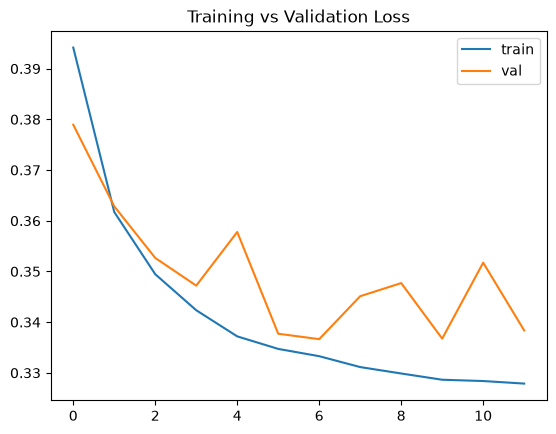

In [50]:

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=25,   # 给上限
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight,
    callbacks=[early_stop]
)

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()

### Step 10: Prediction

In [51]:
y_prob = model.predict(X_test)

y_pred = (y_prob > 0.3)
# Lowering the threshold from 0.5 to 0.3 increases recall,
# which is important for detecting unsafe water.

4593/4593 ━━━━━━━━━━━━━━━━━━━━ 4s 758us/step


### Step 11: Evaluation

In [52]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("F1 Score:", f1_score(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.83      0.90    113133
           1       0.62      0.94      0.75     33819

    accuracy                           0.86    146952
   macro avg       0.80      0.89      0.82    146952
weighted avg       0.90      0.86      0.86    146952

F1 Score: 0.7495237871269665
Confusion Matrix:
[[93778 19355]
 [ 1947 31872]]


The model achieves an overall accuracy of 0.86, indicating good general performance. However, due to class imbalance, greater emphasis is placed on precision, recall, and F1-score.

For the safe class (0), the model achieves high precision (0.98) and strong F1-score (0.90), indicating reliable identification of safe water samples.

More importantly, for the unsafe class (1), the model achieves a very high recall of 0.94, meaning that most unsafe water samples are correctly detected. This is critical in a water quality context, where missing unsafe cases can have serious consequences.

Although the precision for the unsafe class is lower (0.62), indicating some false positives, this reflects a deliberate trade-off. By using a lower classification threshold, the model prioritizes detecting unsafe water over minimizing false alarms.

Overall, the model adopts a conservative strategy, favoring high recall for unsafe cases, which is appropriate for risk-sensitive applications such as water safety monitoring.

该模型的总体准确率为 0.86，表明其整体表现良好。然而，由于类别不平衡，更应关注精确率（precision）、召回率（recall）和 F1 分数。

对于安全类别（0），模型具有较高的精确率（0.98）和较强的 F1 分数（0.90），说明其能够可靠地识别安全水样。

更重要的是，对于不安全类别（1），模型的召回率高达 0.94，这意味着大多数不安全水样都能够被正确检测出来。在水质检测场景中，这一点尤为关键，因为漏检不安全水样可能带来严重后果。

尽管不安全类别的精确率较低（0.62），表明存在一定的误报，但这反映了一种有意的权衡。通过采用较低的分类阈值，模型优先保证检测出不安全水样，而不是尽量减少误报。

总体而言，该模型采取了一种保守策略，更倾向于提高对不安全样本的召回率，这对于水安全监测等风险敏感型应用是合适的。

### Step 13: Permutation Importance (for Neural Network)

#### Step 13.1: Single Feature Permutation


In [53]:
from sklearn.inspection import permutation_importance
def nn_predict(X):
    return (model.predict(X).flatten() > 0.3).astype(int)

baseline = nn_predict(X_test)
baseline_score = f1_score(y_test, baseline)

importances = []
n_repeats = 5

for i, col in enumerate(X.columns):
    scores = []

    for _ in range(n_repeats):
        X_permuted = X_test.copy()

        idx = np.random.permutation(len(X_permuted))
        X_permuted[:, i] = X_permuted[idx, i]

        perm_pred = nn_predict(X_permuted)
        perm_score = f1_score(y_test, perm_pred)

        scores.append(baseline_score - perm_score)

    importance = np.mean(scores)
    importances.append((col, importance))

importance_df = pd.DataFrame(importances, columns=["Feature", "Importance"])
importance_df = importance_df.sort_values(by="Importance", ascending=False)

print(importance_df.head(10))

4593/4593 ━━━━━━━━━━━━━━━━━━━━ 4s 764us/step
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 4s 792us/step
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 4s 889us/step
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step  
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 4s 954us/step
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 4s 905us/step
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 4s 939us/step
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 4s 973us/step
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 5s 978us/step
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 4s 944us/step
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 5s 994us/step
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 4s 863us/step
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 4s 969us/step
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 4s 908us/step
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 4s 957us/step
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 4s 939us/step
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 4s 952us/step
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 4s 929us/step
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 4s 924us/step
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 4s 886us/step
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 4s 919us/step
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 4s 959us/step
4593/4593 

Permutation importance results show that **Manganese, Turbidity, Chloride, and Copper** are the strongest predictors of water quality. These features cause the largest decrease in model performance when permuted, indicating their dominant influence on prediction accuracy.

Other variables such as Odor, Color, and Iron also contribute to the model, but their importance is comparatively lower. Overall, the results suggest that water quality is primarily driven by a small number of key chemical and physical factors.


#### Step 13.2: Pairwise Permutation

In [54]:
# -------------------------------
# Step 1: Compute baseline performance
# -------------------------------
# Predict using the original test set
baseline_pred = nn_predict(X_test)
baseline_score = f1_score(y_test, baseline_pred)

pair_importances = []
n_repeats = 5  # number of repetitions to reduce randomness

# -------------------------------
# Step 2: Select top features based on single permutation
# -------------------------------
# Use previously computed importance_df (from Step 13.1)
feature_names = list(X.columns)

top_features = importance_df.head(5)["Feature"].values
top_indices = [feature_names.index(f) for f in top_features]

# Generate all pair combinations from top features
pairs = list(combinations(top_indices, 2))

# -------------------------------
# Step 3: Perform pairwise permutation
# -------------------------------
for i, j in pairs:
    scores = []

    for _ in range(n_repeats):
        # Copy the test set to avoid modifying original data
        X_permuted = X_test.copy()

        # Generate a shuffled index
        shuffle_idx = np.random.permutation(len(X_permuted))

        # Shuffle BOTH features independently
        X_permuted[:, i] = X_permuted[shuffle_idx, i]
        X_permuted[:, j] = X_permuted[shuffle_idx, j]

        # Predict with permuted data
        perm_pred = nn_predict(X_permuted)
        perm_score = f1_score(y_test, perm_pred)

        # Compute performance drop
        scores.append(baseline_score - perm_score)

    # Average importance over repetitions
    importance = np.mean(scores)

    # Store result with feature names
    pair_importances.append((
        (feature_names[i], feature_names[j]),
        importance
    ))

# -------------------------------
# Step 4: Convert results to DataFrame
# -------------------------------
pair_df = pd.DataFrame(pair_importances, columns=["Feature Pair", "Importance"])
pair_df = pair_df.sort_values(by="Importance", ascending=False)

print(pair_df.head(10))

4593/4593 ━━━━━━━━━━━━━━━━━━━━ 4s 905us/step
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 4s 886us/step
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 4s 898us/step
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 4s 934us/step
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 4s 929us/step
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 4s 917us/step
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 4s 947us/step
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 4s 933us/step
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 4s 941us/step
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 4s 838us/step
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 4s 793us/step
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 4s 794us/step
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 4s 784us/step
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 4s 798us/step
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 4s 796us/step
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 4s 787us/step
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 4s 798us/step
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 4s 779us/step
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 4s 776us/step
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 4s 785us/step
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 4s 783us/step
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 4s 793us/step
4593/4593 

Pairwise permutation analysis reveals that combinations of features such as Manganese with Turbidity, Chloride, and Copper lead to larger performance drops compared to individual features, indicating that these variables jointly influence water quality.

However, the combined importance of feature pairs does not exceed the sum of their individual importances, suggesting that the interactions are not strongly multiplicative but rather reflect additive effects among key predictors.

成对置换分析显示，锰（Manganese）与浊度（Turbidity）、氯化物（Chloride）及铜（Copper）等特征的组合，相比单一特征会导致更显著的性能下降，这表明这些变量共同影响着水质。

然而，特征对的组合重要性并未超过其各自重要性之和；这表明这些变量间的相互作用并非强烈的乘法效应，而是反映了关键预测因子之间的加性效应。

### key findings

To identify the strongest predictors of water quality and investigate potential interaction effects, a combination of exploratory data analysis (EDA), permutation importance, and neural network modeling was applied.

Permutation importance results indicate that **Manganese, Turbidity, Chloride, and Copper** are the most influential predictors, as they lead to the largest decrease in model performance when permuted. These variables represent key chemical and physical factors, suggesting that water quality is primarily driven by metal concentrations, turbidity levels, and disinfection-related components.

Further pairwise permutation analysis shows that feature combinations involving **Manganese** consistently rank among the most important, indicating that it functions as an *interaction hub* and plays a central role when combined with other variables such as Turbidity, Chloride, and Copper. This suggests that water quality is influenced by multiple factors acting jointly rather than independently.

However, when comparing pairwise importance with the sum of individual feature importances, no feature pair exceeds the combined contribution of its individual components. This finding is supported by EDA results, including scatter plots, heatmaps, and correlation analysis, which do not reveal strong nonlinear interaction patterns. Instead, the observed relationships appear smooth and continuous, without clear thresholds or separations.

Overall, these results indicate that while multiple variables jointly influence water quality, there is **no strong multiplicative interaction effect**. The relationships between predictors are primarily **additive**, meaning that each variable contributes independently to the prediction, rather than amplifying each other through strong nonlinear interactions. One possible explanation is that the dataset may be synthetically generated, which can limit the presence of complex real-world interaction structures.

为了识别水质的最强预测因子并探究潜在的交互效应，本研究结合了探索性数据分析（EDA）、置换重要性（permutation importance）以及神经网络建模方法。

置换重要性结果表明，**锰（Manganese）、浊度（Turbidity）、氯化物（Chloride）和铜（Copper）**是最具影响力的预测变量，因为当这些变量被置换时，模型性能下降最为显著。这些变量代表了关键的化学和物理因素，表明水质主要受到金属浓度、浊度水平以及与消毒相关成分的驱动。

进一步的成对置换分析显示，包含**锰（Manganese）**的特征组合始终位列最重要之列，这表明它在与浊度、氯化物和铜等变量结合时，充当了一个“交互枢纽”（interaction hub），发挥着核心作用。这说明水质是由多个因素共同作用影响的，而非各因素独立作用的结果。

然而，在将成对特征的重要性与各单个特征重要性之和进行比较时，没有任何特征组合超过其各自单独贡献的总和。该结论也得到了EDA结果的支持，包括散点图、热力图和相关性分析，这些分析均未显示出明显的非线性交互模式。相反，变量之间的关系表现为平滑且连续，没有明显的阈值或分界。

总体而言，这些结果表明，尽管多个变量共同影响水质，但并不存在显著的乘性交互效应。各预测变量之间的关系主要是加性关系，即每个变量独立地对预测结果作出贡献，而不是通过强烈的非线性交互相互放大。一种可能的解释是，该数据集可能是合成生成的，从而限制了复杂现实世界交互结构的出现。